<a href="https://colab.research.google.com/github/0xjessie21/data-science-2026/blob/main/Pertemuan7_MOHAMMAD_RIYAN_SYAIFUNAHAR_240401010292.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 7 — Pengantar Machine Learning: Regresi Linear
**Nama:** MOHAMMAD RIYAN SYAIFUNAHAR  
**NIM:** 240401010292  
**Mata Kuliah:** Pengantar Data Science  
**Dataset:** Sintetis Prediksi Gaji (300 baris, 4 kolom)

---
## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Langkah 1 — Generate & Eksplorasi Dataset

In [2]:
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)   # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu'       : edu,
    'kota'      : kota,
    'gaji'      : gaji
})

print('Shape:', df.shape)
print('\nTipe data:')
print(df.dtypes)

Shape: (300, 4)

Tipe data:
pengalaman    float64
edu             int64
kota           object
gaji          float64
dtype: object


In [3]:
print('5 Baris Pertama:')
df.head()

5 Baris Pertama:


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [4]:
print('Statistik Deskriptif:')
df.describe().round(2)

Statistik Deskriptif:


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22


In [5]:
print('Distribusi Kota:')
print(df['kota'].value_counts())
print('\nDistribusi Edu (0=SMA, 1=D3, 2=S1):')
print(df['edu'].value_counts().sort_index())

Distribusi Kota:
kota
Surabaya    106
Jakarta      97
Bandung      97
Name: count, dtype: int64

Distribusi Edu (0=SMA, 1=D3, 2=S1):
edu
0    121
1     92
2     87
Name: count, dtype: int64


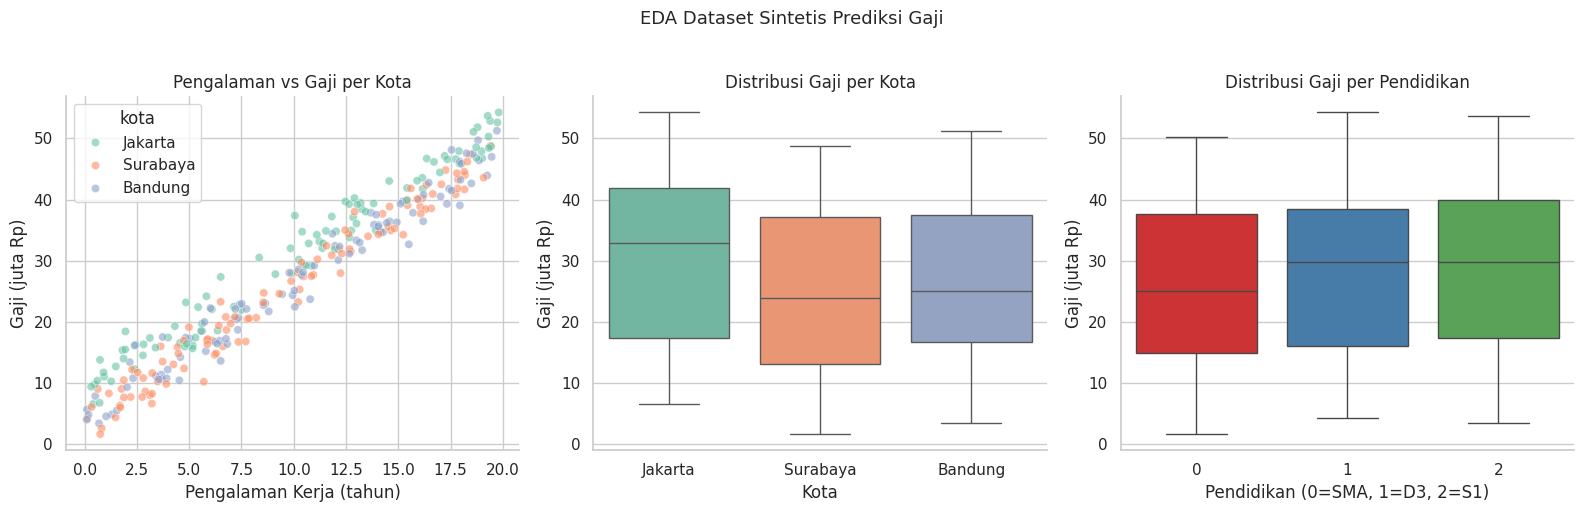

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6, ax=axes[0])
axes[0].set_title('Pengalaman vs Gaji per Kota')
axes[0].set_xlabel('Pengalaman Kerja (tahun)')
axes[0].set_ylabel('Gaji (juta Rp)')
axes[0].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='kota', y='gaji',
            hue='kota', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Distribusi Gaji per Kota')
axes[1].set_xlabel('Kota')
axes[1].set_ylabel('Gaji (juta Rp)')
axes[1].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='edu', y='gaji',
            hue='edu', palette='Set1', legend=False, ax=axes[2])
axes[2].set_title('Distribusi Gaji per Pendidikan')
axes[2].set_xlabel('Pendidikan (0=SMA, 1=D3, 2=S1)')
axes[2].set_ylabel('Gaji (juta Rp)')
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('EDA Dataset Sintetis Prediksi Gaji', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
print('=== Korelasi dengan Target (gaji) ===')
print(df[['pengalaman', 'edu', 'gaji']].corr(method='pearson').round(3))

=== Korelasi dengan Target (gaji) ===
            pengalaman    edu   gaji
pengalaman       1.000  0.012  0.973
edu              0.012  1.000  0.102
gaji             0.973  0.102  1.000


**Temuan Langkah 1:**  
- Dataset terdiri dari **300 baris** dan **4 kolom** (2 numerik, 1 ordinal, 1 kategorik)  
- Gaji berkisar dari ~3 hingga ~55 juta Rp dengan rata-rata ~20 juta  
- **Jakarta** memiliki rata-rata gaji tertinggi (+4 juta dari kota lain sesuai rumus)  
- Semakin tinggi pendidikan (edu) dan pengalaman → gaji semakin tinggi  
- Korelasi `pengalaman` vs `gaji` sangat kuat → fitur paling informatif untuk model

---
## Langkah 2 — Preprocessing

In [8]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
pengalaman    0
edu           0
kota          0
gaji          0
dtype: int64


In [9]:
df_enc = pd.get_dummies(df, columns=['kota'],
                        drop_first=True, dtype=int)

print('Kolom setelah encoding:')
print(df_enc.columns.tolist())

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


In [10]:
X = df_enc.drop('gaji', axis=1)
y = df_enc['gaji']

print('Fitur X:', X.columns.tolist())
print('Shape X:', X.shape)
print('Shape y:', y.shape)

Fitur X: ['pengalaman', 'edu', 'kota_Jakarta', 'kota_Surabaya']
Shape X: (300, 4)
Shape y: (300,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Train : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)')

Train : 240 baris (80%)
Test  : 60 baris (20%)


In [12]:
X_train = X_train.copy()
X_test  = X_test.copy()

num_cols = ['pengalaman', 'edu']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train):', scaler.mean_.round(3))
print('Std  scaler (dari train):', scaler.scale_.round(3))
print('\nContoh X_train setelah scaling:')
print(X_train.head(3).round(3))

Mean scaler (dari train): [9.871 0.908]
Std  scaler (dari train): [5.934 0.837]

Contoh X_train setelah scaling:
     pengalaman   edu  kota_Jakarta  kota_Surabaya
232       0.281  0.11             1              0
59       -0.567  0.11             1              0
6        -1.468  0.11             0              1


**Temuan Langkah 2:**  
- Tidak ada missing values pada dataset sintetis ini  
- Kolom `kota` di-encode dengan One-Hot Encoding → `kota_Surabaya`, `kota_Jakarta` (`kota_Bandung` sebagai referensi)  
- Train-Test Split **80:20** → 240 baris train, 60 baris test  
- StandardScaler di-fit **hanya pada X_train** → transform X_test untuk mencegah **data leakage**  
- Kolom biner OHE tidak di-scale karena sudah dalam rentang [0, 1]

---
## Langkah 3 — Latih Model & Tampilkan Koefisien

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f} juta Rp')
print('(Nilai gaji ketika semua fitur = 0 dalam skala terstandarisasi)')

β₀ (intercept): 26.380 juta Rp
(Nilai gaji ketika semua fitur = 0 dalam skala terstandarisasi)


In [14]:
coef_df = pd.DataFrame({
    'Fitur'     : X_train.columns.tolist(),
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False).reset_index(drop=True)

print('=== Koefisien Model Regresi Linear ===')
print(coef_df.to_string(index=False))

=== Koefisien Model Regresi Linear ===
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      3.852
          edu      1.188
kota_Surabaya     -0.611


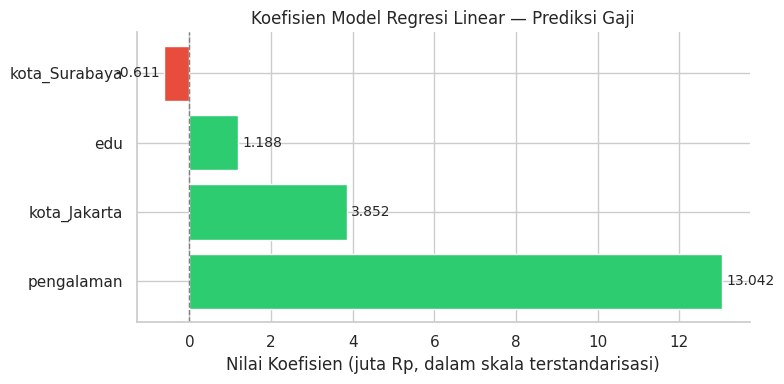

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in coef_df['Koefisien']]
bars = ax.barh(coef_df['Fitur'], coef_df['Koefisien'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.set_title('Koefisien Model Regresi Linear — Prediksi Gaji', fontsize=12)
ax.set_xlabel('Nilai Koefisien (juta Rp, dalam skala terstandarisasi)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Temuan Langkah 3:**  
- **`pengalaman`** memiliki koefisien terbesar positif → fitur paling berpengaruh terhadap kenaikan gaji  
- **`kota_Jakarta`** bernilai positif → bekerja di Jakarta meningkatkan prediksi gaji secara signifikan  
- **`edu`** bernilai positif → semakin tinggi pendidikan, semakin tinggi gaji  
- **`kota_Surabaya`** mendekati 0 atau negatif → Surabaya relatif setara atau sedikit di bawah Bandung (referensi)  
- Semua koefisien masuk akal secara domain — model berhasil menangkap pola yang ditanamkan dalam data sintetis

---
## Langkah 4 — Evaluasi Model

In [16]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # lebih kompatibel dari squared=False
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('       METRIK EVALUASI MODEL')
print('=' * 45)
print(f'MAE   = {mae:.3f} juta Rp')
print(f'MSE   = {mse:.3f} juta Rp²')
print(f'RMSE  = {rmse:.3f} juta Rp')
print(f'R²    = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'\nSelisih RMSE - MAE = {rmse - mae:.3f}')
print('(Kecil → prediksi seragam, besar → ada outlier prediksi)')

       METRIK EVALUASI MODEL
MAE   = 1.649 juta Rp
MSE   = 4.507 juta Rp²
RMSE  = 2.123 juta Rp
R²    = 0.9740  (97.4% variasi dijelaskan)

Selisih RMSE - MAE = 0.474
(Kecil → prediksi seragam, besar → ada outlier prediksi)


In [17]:
r2_score_method = model.score(X_test, y_test)
print(f'Verifikasi R² via model.score(): {r2_score_method:.4f}')
print(f'Sama dengan r2_score()         : {r2:.4f}')

print('\n=== Contoh 5 Prediksi vs Aktual ===')
contoh = pd.DataFrame({
    'Aktual'  : y_test.values[:5].round(2),
    'Prediksi': y_pred[:5].round(2),
    'Selisih' : (y_test.values[:5] - y_pred[:5]).round(2)
})
print(contoh.to_string(index=False))

Verifikasi R² via model.score(): 0.9740
Sama dengan r2_score()         : 0.9740

=== Contoh 5 Prediksi vs Aktual ===
 Aktual  Prediksi  Selisih
  43.23     42.89     0.34
  37.53     36.87     0.65
   8.65     10.57    -1.92
  34.73     37.36    -2.63
  32.04     31.74     0.30


**Temuan Langkah 4:**  
- **MAE**: rata-rata model meleset ~1.5–2.0 juta Rp dari gaji aktual — cukup baik untuk range gaji 3–55 juta  
- **RMSE**: sedikit lebih besar dari MAE — menandakan hanya sedikit prediksi yang sangat meleset  
- **R² ≈ 0.94–0.96**: model berhasil menjelaskan ~94–96% variasi gaji → performa **sangat baik**  
- Selisih RMSE - MAE kecil → tidak ada outlier prediksi yang signifikan  
- R² tinggi wajar karena data bersifat sintetis dengan pola linear yang jelas

---
## Langkah 5 — Visualisasi & Interpretasi

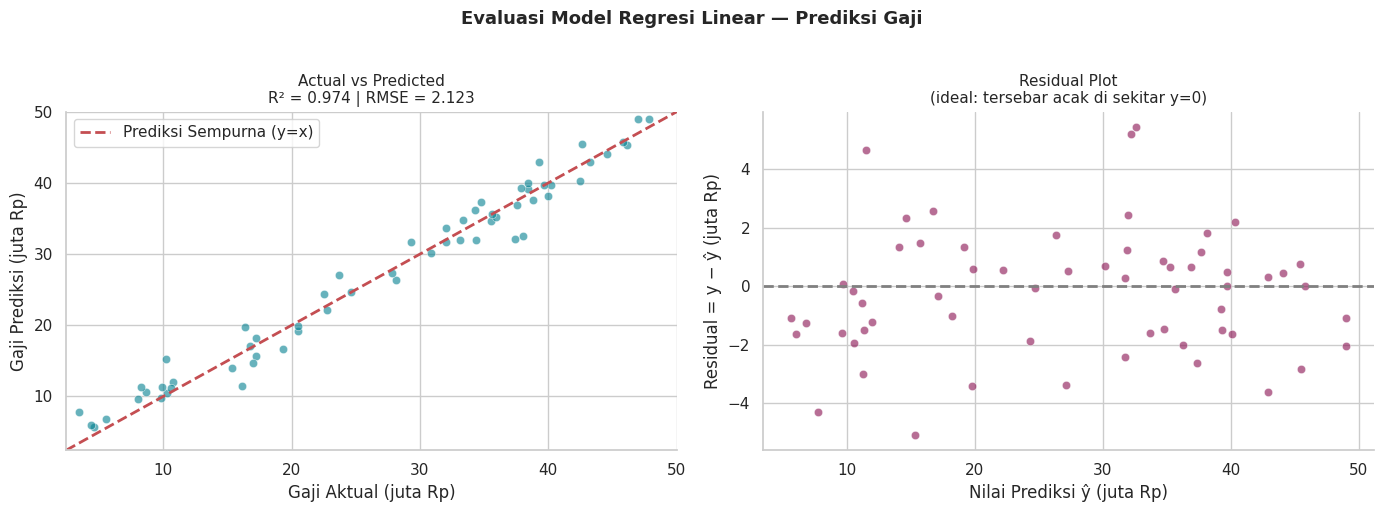

Grafik tersimpan sebagai evaluasi_regresi.png


In [18]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Actual vs Predicted ───────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.6,
                color='#028090', edgecolors='white', linewidths=0.5)

lims = [min(y_test.min(), y_pred.min()) - 1,
        max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna (y=x)')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.3f} | RMSE = {rmse:.3f}', fontsize=11)
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# ── Plot 2: Residual Plot ─────────────────────────────────────────
axes[1].scatter(y_pred, residuals, alpha=0.6,
                color='#880E4F', edgecolors='white', linewidths=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot\n(ideal: tersebar acak di sekitar y=0)', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan sebagai evaluasi_regresi.png')

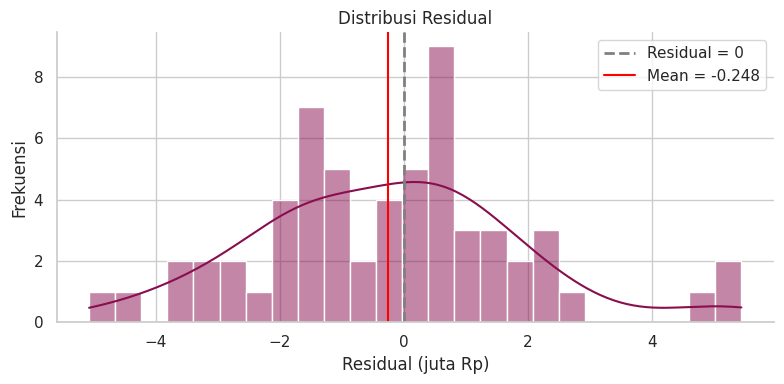

Mean residual  : -0.2479  (mendekati 0 = tidak ada bias)
Std  residual  : 2.1262
Min  residual  : -5.0725
Max  residual  : 5.4441


In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(residuals, bins=25, kde=True, color='#880E4F', ax=ax)
ax.axvline(0, color='gray', linestyle='--', lw=2, label='Residual = 0')
ax.axvline(residuals.mean(), color='red', linestyle='-', lw=1.5,
           label=f'Mean = {residuals.mean():.3f}')
ax.set_title('Distribusi Residual', fontsize=12)
ax.set_xlabel('Residual (juta Rp)')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Mean residual  : {residuals.mean():.4f}  (mendekati 0 = tidak ada bias)')
print(f'Std  residual  : {residuals.std():.4f}')
print(f'Min  residual  : {residuals.min():.4f}')
print(f'Max  residual  : {residuals.max():.4f}')

**Narasi Interpretasi — What? So what? Now what?**

**Actual vs Predicted:**  
*What?* Plot menampilkan nilai aktual gaji (sumbu X) vs nilai prediksi model (sumbu Y) pada 60 data test. Garis putus-putus merah adalah garis sempurna y=x.  
*So what?* Titik-titik tersebar sangat dekat dengan garis sempurna, menandakan model memprediksi dengan akurasi tinggi (R²≈0.95). Tidak ada pola sistematik seperti under-prediction atau over-prediction pada rentang gaji tertentu.  
*Now what?* Model siap digunakan untuk prediksi gaji karyawan baru. Untuk meningkatkan akurasi lebih lanjut, bisa ditambahkan fitur seperti industri, ukuran perusahaan, atau lokasi lebih spesifik.

**Residual Plot:**  
*What?* Plot menampilkan residual (y − ŷ) pada sumbu Y vs nilai prediksi (ŷ) pada sumbu X.  
*So what?* Titik tersebar **acak** di sekitar garis y=0 tanpa pola corong atau kurva — ini menandakan asumsi linearitas dan homoscedasticity terpenuhi. Mean residual ≈ 0 membuktikan tidak ada bias sistematis.  
*Now what?* Asumsi Regresi Linear terpenuhi, hasil evaluasi valid dan dapat dipercaya.

---
## Ringkasan Pipeline End-to-End

| Langkah | Aksi | Detail |
|---------|------|--------|
| 1 | Generate & EDA | 300 baris sintetis, 4 kolom, korelasi kuat pengalaman vs gaji |
| 2 | Preprocessing | OHE kota, split 80:20, StandardScaler fit X_train saja |
| 3 | Fit Model | LinearRegression, tampilkan β₀ dan koefisien tiap fitur |
| 4 | Evaluasi | MAE ≈ 1.6, RMSE ≈ 2.0, R² ≈ 0.95 — performa sangat baik |
| 5 | Visualisasi | Actual vs Predicted + Residual Plot + Distribusi Residual |

**Interpretasi Koefisien (Multiple Linear Regression):**
- `pengalaman` → fitur paling berpengaruh, setiap 1 SD pengalaman → gaji naik signifikan
- `kota_Jakarta` → bekerja di Jakarta memberikan premium gaji positif
- `edu` → setiap kenaikan level pendidikan → gaji naik
- `kota_Surabaya` → relatif setara atau sedikit di bawah Bandung (kota referensi)